# MISTIC kernel comparison vs Extra Trees playground

Use this notebook to compare RBF MISTIC, mixed linear–RBF MISTIC with shared features, mixed linear–RBF MISTIC with kernel-specific selection units, and Extra Trees on paired blind folds across synthetic classification scenarios. All MISTIC variants use the unified `greedy_forward_selection` API and `combined_rank`; the separate mixed case selects `(kernel_id, perturbation_set)` units independently. Edit the configuration cell, inspect the resolved experiment, and then enable `RUN_EXPERIMENT`. Results are checkpointed under a hash of the complete configuration, so changing a setting cannot silently reuse incompatible fits.

The known signal mask is used only after prediction to evaluate feature recovery; it is never supplied to either model. After generation, columns and the signal mask are passed through the same deterministic seed-specific permutation, so signal variables are dispersed rather than fixed at consecutive leading indices.

In [64]:
from dataclasses import asdict, replace
from hashlib import sha256
from pathlib import Path
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import StratifiedKFold

from mistic.examples.classification_benchmark_suite import (
    BenchmarkConfig, DatasetSpec, IndependentMixedMisticClassifier, MisticClassifier,
    MixedMisticClassifier, _safe_split_count,
    dataset_specs, evaluate_method, feature_stability, make_dataset,
    sklearn_methods,
)

sns.set_theme(style='whitegrid', context='notebook')
EXAMPLE_DIR = Path.cwd()
if EXAMPLE_DIR.name != 'examples':
    EXAMPLE_DIR = Path('mistic/examples')
OUTPUT_ROOT = EXAMPLE_DIR / 'mistic_extra_trees_playground_results'

## Experiment configuration

Available scenarios are `clean_linear`, `correlated`, `nonlinear`, and `noisy_imbalanced`. Before fitting any MISTIC variant, normalized feature profiles are clustered into `MISTIC_NUM_PERTURBATION_CLUSTERS` groups; each group is an indivisible perturbation set and its medoid seeds forward selection. `MISTIC_MAX_SELECTION_FEATURES` counts kernel-feature assignments in the separate mixed case, whereas reported `selected_feature_count` is the number of unique original columns. For a linear kernel, gamma settings are ignored.

In [ ]:
# Dataset design
SCENARIOS = ('correlated', 'nonlinear', 'noisy_imbalanced')
SAMPLE_SIZES = (50,)
FEATURE_COUNTS = (1000,)
DATA_SEEDS = (2026, 2027, 2028)
OUTER_FOLDS = 3
INNER_FOLDS = 3

# Current preferred MISTIC configuration
MISTIC_MEMBERS = 10
MISTIC_RANK_WEIGHT = 0.75
MISTIC_FEATURE_FRACTION = 0.20
MISTIC_NUM_PERTURBATION_CLUSTERS = 100
MISTIC_MAX_FEATURES = None          # e.g. 20, or None for fraction scaling
MISTIC_CLASS_WEIGHT = True
MISTIC_TUNE_EACH_STEP = True
MISTIC_ADDITION_FACTOR = 0.20
MISTIC_SCORE_WEIGHT = 0.50          # AUC weight; F1 weight is 1 - this
MISTIC_KERNEL = 'rbf'               # 'rbf' or 'linear'

# Hyperparameter candidates
MISTIC_PARAMETER_STRATEGY = 'latin_hypercube'  # or 'grid'
MISTIC_LHS_TRIALS = 10
MISTIC_C_BOUNDS = (0.1, 8.0)
MISTIC_GAMMA_BOUNDS = (1e-10, 4)
MISTIC_C_VALUES = (0.25, 1.0, 4.0)
MISTIC_GAMMA_VALUES = (2**-9, 2**-7, 2**-5)
MISTIC_MIXED_LINEAR_WEIGHTS = (0, 0.25, 0.5, 0.75, 1.0)
MISTIC_MAX_SELECTION_FEATURES = 200  # kernel-feature assignments for the separate mixed case
MISTIC_NUM_INITIAL_SELECTION_UNITS = 1

RANDOM_SEED = 42
RUN_EXPERIMENT = True  # Change to True when ready
FORCE_RERUN = True     # True overwrites checkpoints for this exact config

In [66]:
config = BenchmarkConfig(
    sample_sizes=SAMPLE_SIZES, feature_counts=FEATURE_COUNTS,
    scenarios=SCENARIOS, data_seeds=DATA_SEEDS,
    outer_folds=OUTER_FOLDS, inner_folds=INNER_FOLDS,
    mistic_members=MISTIC_MEMBERS,
    mistic_rank_weight=MISTIC_RANK_WEIGHT,
    mistic_feature_fraction=MISTIC_FEATURE_FRACTION,
    mistic_num_perturbation_clusters=MISTIC_NUM_PERTURBATION_CLUSTERS,
    mistic_max_features=MISTIC_MAX_FEATURES,
    mistic_class_weight=MISTIC_CLASS_WEIGHT,
    mistic_tune_models_each_step=MISTIC_TUNE_EACH_STEP,
    mistic_addition_factor=MISTIC_ADDITION_FACTOR,
    mistic_score_weight=MISTIC_SCORE_WEIGHT,
    mistic_parameter_strategy=MISTIC_PARAMETER_STRATEGY,
    mistic_kernel=MISTIC_KERNEL,
    mistic_lhs_trials=MISTIC_LHS_TRIALS,
    mistic_c_bounds=MISTIC_C_BOUNDS,
    mistic_gamma_bounds=MISTIC_GAMMA_BOUNDS,
    mistic_c_values=MISTIC_C_VALUES,
    mistic_gamma_values=MISTIC_GAMMA_VALUES,
    mistic_mixed_linear_weights=MISTIC_MIXED_LINEAR_WEIGHTS,
    mistic_max_selection_features=MISTIC_MAX_SELECTION_FEATURES,
    mistic_num_initial_selection_units=MISTIC_NUM_INITIAL_SELECTION_UNITS,
    random_seed=RANDOM_SEED,
)

payload = json.dumps(asdict(config), sort_keys=True, default=list)
CONFIG_ID = sha256(payload.encode()).hexdigest()[:12]
RUN_DIR = OUTPUT_ROOT / CONFIG_ID
CHECKPOINT_DIR = RUN_DIR / 'checkpoints'
RUN_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
(RUN_DIR / 'config.json').write_text(json.dumps(asdict(config), indent=2))

resolved = pd.DataFrame([
    {
        'n_features': p,
        'perturbation_clusters': min(p, MISTIC_NUM_PERTURBATION_CLUSTERS),
        'max_unique_features': MISTIC_MAX_FEATURES or max(1, round(MISTIC_FEATURE_FRACTION*p)),
        'max_selection_features': min(2 * p, MISTIC_MAX_SELECTION_FEATURES),
    } for p in FEATURE_COUNTS
])
print(f'Configuration: {CONFIG_ID}')
print(f'Datasets: {len(SCENARIOS)*len(SAMPLE_SIZES)*len(FEATURE_COUNTS)*len(DATA_SEEDS)}')
print(f'Output: {RUN_DIR.resolve()}')
display(resolved)

Configuration: 82045817705d
Datasets: 9
Output: /Users/chriskieslich/Library/CloudStorage/Dropbox-GaTech/Christopher Kieslich/006_Code/interpretable-explainable-svms/mistic/examples/mistic_extra_trees_playground_results/82045817705d


,n_features,perturbation_clusters,max_unique_features,max_selection_features
0,1000,100,200,40


## Paired benchmark runner

All four methods use the same stratified outer folds. Every completed dataset is written immediately. The MISTIC wrappers share the unified forward-selection entry point; only their kernel expression and shared-versus-independent unit routing differ. Extra Trees is configured identically to the main benchmark.

In [67]:
def benchmark_pair(spec, config):
    X, y, signal_mask = make_dataset(spec)
    n_outer = _safe_split_count(y, config.outer_folds)
    outer = StratifiedKFold(
        n_outer, shuffle=True,
        random_state=config.random_seed + spec.data_seed,
    )
    rows = []
    for fold, (train, test) in enumerate(outer.split(X, y)):
        seed = config.random_seed + 1000*spec.data_seed + fold
        inner = _safe_split_count(y.iloc[train], config.inner_folds)
        methods = {
            'mistic_unified': MisticClassifier(config, seed),
            'mistic_mixed': MixedMisticClassifier(config, seed),
            'mistic_mixed_independent': IndependentMixedMisticClassifier(config, seed),
            'extra_trees': sklearn_methods(seed, inner)['extra_trees'],
        }
        for name, estimator in methods.items():
            try:
                result = {
                    'status': 'ok', 'error_type': None, 'error_message': None,
                    **evaluate_method(
                        name, estimator, X.iloc[train], y.iloc[train],
                        X.iloc[test], y.iloc[test], signal_mask, seed,
                    ),
                }
            except Exception as error:
                result = {
                    'method': name, 'status': 'failed',
                    'error_type': type(error).__name__,
                    'error_message': str(error)[:1000],
                }
            rows.append({**asdict(spec), 'outer_fold': fold, **result})
    return pd.DataFrame(rows)


def run_paired_benchmark(config, force=False):
    completed = []
    specs = dataset_specs(config)
    for index, spec in enumerate(specs, start=1):
        path = CHECKPOINT_DIR / f'{spec.name}.csv'
        if path.exists() and not force:
            frame = pd.read_csv(path)
            state = 'cached'
        else:
            frame = benchmark_pair(spec, config)
            frame.to_csv(path, index=False)
            state = 'completed'
        completed.append(frame)
        print(f'[{index:>3}/{len(specs)}] {state}: {spec.name}', flush=True)
    results = pd.concat(completed, ignore_index=True)
    results.to_csv(RUN_DIR / 'all_results.csv', index=False)
    return results

In [68]:
if RUN_EXPERIMENT:
    results = run_paired_benchmark(config, force=FORCE_RERUN)
elif (RUN_DIR / 'all_results.csv').exists():
    results = pd.read_csv(RUN_DIR / 'all_results.csv')
    print('Loaded cached results.')
else:
    results = pd.DataFrame()
    print('Ready. Set RUN_EXPERIMENT=True and rerun from the configuration cell.')

Number of Features: 15, Score: 0.801
Number of Features: 55, Score: 0.776
Number of Features: 88, Score: 0.694
Number of Features: 115, Score: 0.683
Number of Features: 136, Score: 0.750
Number of Features: 153, Score: 0.728
Number of Features: 166, Score: 0.751
Number of Features: 175, Score: 0.738
Number of Features: 184, Score: 0.733
Number of Features: 193, Score: 0.751
Number of Features: 199, Score: 0.739
Number of Features: 200, Score: 0.752
Number of Features: 1000, Score: 0.744
Number of Features: 12, Score: 0.877
Number of Features: 53, Score: 0.703
Number of Features: 84, Score: 0.665
Number of Features: 111, Score: 0.611
Number of Features: 132, Score: 0.613
Number of Features: 149, Score: 0.576
Number of Features: 162, Score: 0.581
Number of Features: 173, Score: 0.504
Number of Features: 181, Score: 0.522
Number of Features: 190, Score: 0.523
Number of Features: 196, Score: 0.524
Number of Features: 199, Score: 0.530
Number of Features: 1000, Score: 0.641
Kernel features:

KeyboardInterrupt: 

## Results and diagnostics

In [ ]:
METRICS = [
    'roc_auc', 'pr_auc', 'f1', 'balanced_accuracy', 'mcc',
    'signal_recall_at_k', 'feature_average_precision',
    'selected_feature_count', 'elapsed_seconds',
]

if not results.empty:
    failures = results[results.status != 'ok'][
        ['name', 'outer_fold', 'method', 'error_type', 'error_message']
    ]
    if len(failures):
        display(failures)
    successful = results[results.status == 'ok'].copy()
    overall = successful.groupby('method')[METRICS].agg(['mean', 'std', 'count'])
    scenario_summary = successful.groupby(['scenario', 'method'])[METRICS].agg(['mean', 'std', 'count'])
    overall.to_csv(RUN_DIR / 'overall_summary.csv')
    scenario_summary.to_csv(RUN_DIR / 'scenario_summary.csv')
    display(overall)
    display(scenario_summary)
    

roc_auc                    pr_auc                  \
                              mean       std count      mean       std count   
method                                                                         
extra_trees               0.524365  0.153947    27  0.491908  0.167302    27   
mistic_mixed              0.526492  0.132845    27  0.504804  0.149518    27   
mistic_mixed_independent  0.566195  0.152893    27  0.558171  0.155920    27   
mistic_unified            0.550437  0.150451    27  0.518583  0.164844    27   

                                f1                 balanced_accuracy  ...  \
                              mean       std count              mean  ...   
method                                                                ...   
extra_trees               0.260589  0.266959    27          0.524361  ...   
mistic_mixed              0.430368  0.214498    27          0.519101  ...   
mistic_mixed_independent  0.417641  0.269925    27          0.547254  ...   
mistic_unified            0.388578  0.276999    27          0.514335  ...   

                         signal_recall_at_k feature_average_precision  \
                                      count                      mean   
method                                                                  
extra_trees                              27                  0.044804   
mistic_mixed                             27                  0.030367   
mistic_mixed_independent                 27                  0.027384   
mistic_unified                           27                  0.030067   

                                         selected_feature_count             \
                               std count                   mean        std   
method                                                                       
extra_trees               0.035215    27                    NaN        NaN   
mistic_mixed              0.016606    27              24.925926   4.084925   
mistic_mixed_independent  0.014975    27              32.814815   6.101936   
mistic_unified            0.021015    27              33.592593  35.870772   

                               elapsed_seconds                  
                         count            mean       std count  
method                                                          
extra_trees                  0        1.894691  1.414044    27  
mistic_mixed                27       10.765966  1.037140    27  
mistic_mixed_independent    27        3.315627  0.562064    27  
mistic_unified              27        8.835036  0.723513    27  

[4 rows x 27 columns]

roc_auc                    pr_auc  \
                                               mean       std count      mean   
scenario         method                                                         
correlated       extra_trees               0.539572  0.136044     9  0.559580   
                 mistic_mixed              0.497134  0.101676     9  0.539107   
                 mistic_mixed_independent  0.534171  0.139602     9  0.591150   
                 mistic_unified            0.518959  0.144195     9  0.563510   
noisy_imbalanced extra_trees               0.506130  0.197565     9  0.336934   
                 mistic_mixed              0.541641  0.173191     9  0.372424   
                 mistic_mixed_independent  0.606736  0.205252     9  0.458543   
                 mistic_unified            0.595314  0.162815     9  0.380883   
nonlinear        extra_trees               0.527392  0.137257     9  0.579211   
                 mistic_mixed              0.540702  0.124768     9  0.602879   
                 mistic_mixed_independent  0.557677  0.106165     9  0.624819   
                 mistic_unified            0.537037  0.150605     9  0.611356   

                                                                 f1            \
                                                std count      mean       std   
scenario         method                                                         
correlated       extra_trees               0.110571     9  0.233132  0.193175   
                 mistic_mixed              0.086532     9  0.464085  0.123348   
                 mistic_mixed_independent  0.131264     9  0.510165  0.198856   
                 mistic_unified            0.147051     9  0.565437  0.112524   
noisy_imbalanced extra_trees               0.157441     9  0.000000  0.000000   
                 mistic_mixed              0.155099     9  0.250000  0.239357   
                 mistic_mixed_independent  0.194134     9  0.239152  0.277979   
                 mistic_unified            0.131091     9  0.092593  0.188398   
nonlinear        extra_trees               0.114927     9  0.548634  0.154003   
                 mistic_mixed              0.096191     9  0.577018  0.122279   
                 mistic_mixed_independent  0.081887     9  0.503608  0.257279   
                 mistic_unified            0.127357     9  0.507705  0.226936   

                                                balanced_accuracy  ...  \
                                          count              mean  ...   
scenario         method                                            ...   
correlated       extra_trees                  9          0.515212  ...   
                 mistic_mixed                 9          0.494929  ...   
                 mistic_mixed_independent     9          0.530093  ...   
                 mistic_unified               9          0.523920  ...   
noisy_imbalanced extra_trees                  9          0.500000  ...   
                 mistic_mixed                 9          0.525336  ...   
                 mistic_mixed_independent     9          0.570004  ...   
                 mistic_unified               9          0.518315  ...   
nonlinear        extra_trees                  9          0.557870  ...   
                 mistic_mixed                 9          0.537037  ...   
                 mistic_mixed_independent     9          0.541667  ...   
                 mistic_unified               9          0.500772  ...   

                                          signal_recall_at_k  \
                                                       count   
scenario         method                                        
correlated       extra_trees                               9   
                 mistic_mixed                              9   
                 mistic_mixed_independent                  9   
                 mistic_unified                            9   
noisy_imbalanced extra_trees                         

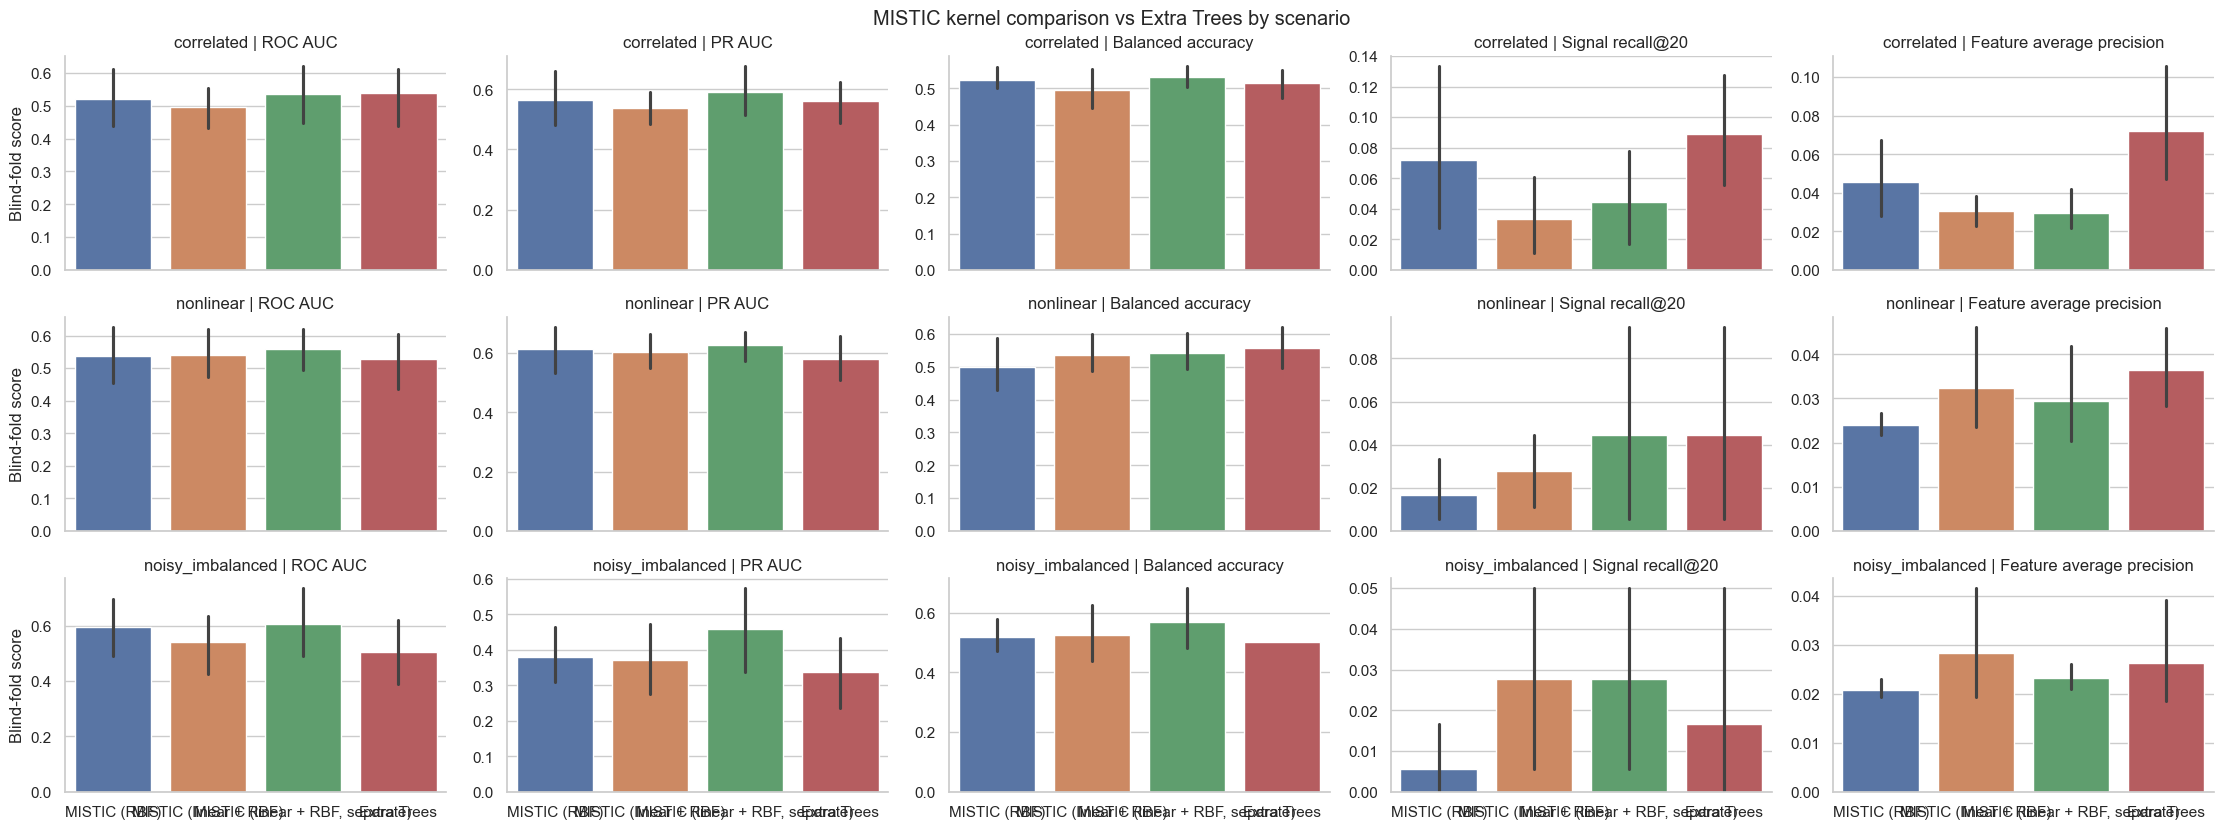

In [ ]:
if not results.empty:
    labels = {
        'mistic_unified': 'MISTIC (RBF)',
        'mistic_mixed': 'MISTIC (linear + RBF)',
        'mistic_mixed_independent': 'MISTIC (linear + RBF, separate)',
        'extra_trees': 'Extra Trees',
    }
    successful['Model'] = successful.method.map(labels)
    plot_metrics = {
        'roc_auc': 'ROC AUC',
        'pr_auc': 'PR AUC',
        'balanced_accuracy': 'Balanced accuracy',
        'signal_recall_at_k': 'Signal recall@20',
        'feature_average_precision': 'Feature average precision',
    }
    long = successful.melt(
        id_vars=['scenario', 'n_samples', 'n_features', 'Model'],
        value_vars=list(plot_metrics), var_name='metric', value_name='value',
    )
    long['metric'] = long.metric.map(plot_metrics)
    grid = sns.catplot(
        data=long, x='Model', y='value', hue='Model',
        row='scenario', col='metric', kind='bar', errorbar=('ci', 95),
        sharey=False, height=2.8, aspect=1.6, legend=False,
    )
    grid.set_axis_labels('', 'Blind-fold score')
    grid.set_titles(row_template='{row_name}', col_template='{col_name}')
    grid.figure.suptitle('MISTIC kernel comparison vs Extra Trees by scenario', y=1.01)
    grid.figure.savefig(RUN_DIR / 'scenario_comparison.png', dpi=180, bbox_inches='tight')
    plt.show()

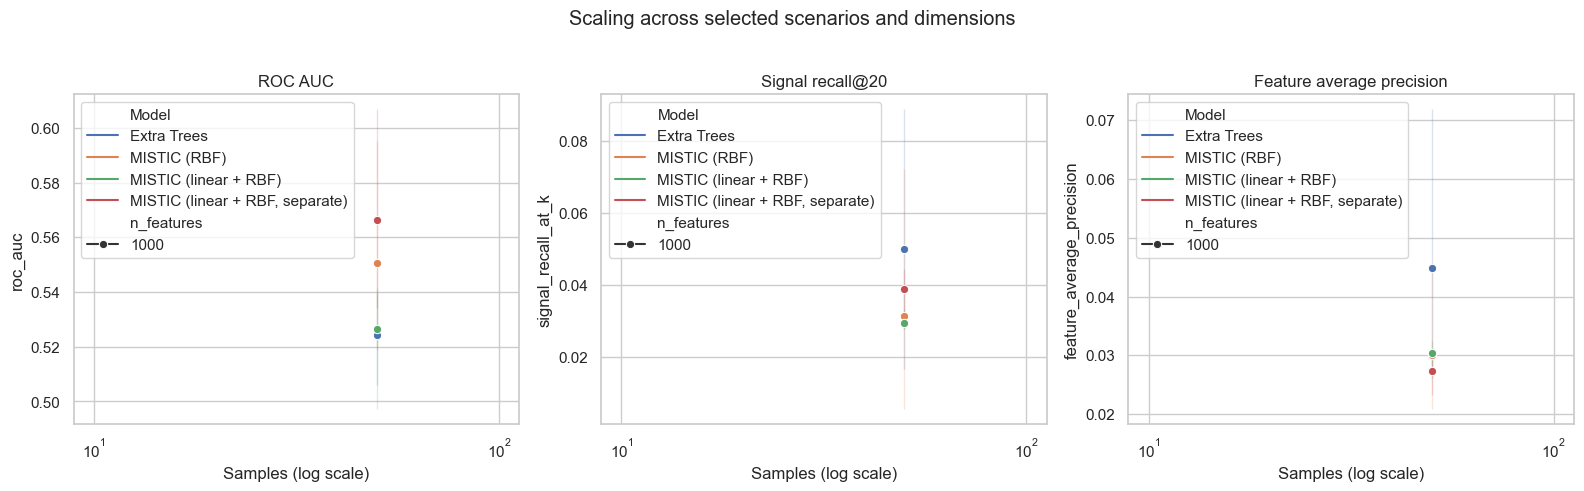

,name,method,mean_top_k_jaccard
0,correlated_n50_p1000_s2026,extra_trees,0.071598
1,correlated_n50_p1000_s2026,mistic_mixed,0.017094
2,correlated_n50_p1000_s2026,mistic_mixed_independent,0.017094
3,correlated_n50_p1000_s2026,mistic_unified,0.000000
4,correlated_n50_p1000_s2027,extra_trees,0.017544
5,correlated_n50_p1000_s2027,mistic_mixed,0.017094
6,correlated_n50_p1000_s2027,mistic_mixed_independent,0.008547
7,correlated_n50_p1000_s2027,mistic_unified,0.017544
8,correlated_n50_p1000_s2028,extra_trees,0.081081
9,correlated_n50_p1000_s2028,mistic_mixed,0.008547


In [ ]:
if not results.empty:
    scaling = successful.groupby(
        ['scenario', 'n_samples', 'n_features', 'Model'], as_index=False
    )[['roc_auc', 'signal_recall_at_k', 'feature_average_precision']].mean()
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
    for axis, metric, title in zip(
        axes,
        ['roc_auc', 'signal_recall_at_k', 'feature_average_precision'],
        ['ROC AUC', 'Signal recall@20', 'Feature average precision'],
    ):
        sns.lineplot(
            data=scaling, x='n_samples', y=metric, hue='Model',
            style='n_features', markers=True, dashes=False, ax=axis,
        )
        axis.set_xscale('log')
        axis.set_title(title)
        axis.set_xlabel('Samples (log scale)')
    fig.suptitle('Scaling across selected scenarios and dimensions', y=1.02)
    fig.tight_layout()
    fig.savefig(RUN_DIR / 'scaling_comparison.png', dpi=180, bbox_inches='tight')
    plt.show()

    stability = feature_stability(successful)
    stability.to_csv(RUN_DIR / 'feature_stability.csv', index=False)
    display(stability)

## Comparing experiments

Each configuration receives its own directory. Use the cell below after running multiple configurations to compare their saved summaries without mixing checkpoints.

In [ ]:
experiment_rows = []
for result_path in sorted(OUTPUT_ROOT.glob('*/all_results.csv')):
    frame = pd.read_csv(result_path)
    frame = frame[frame.status == 'ok'].copy()
    frame['configuration'] = result_path.parent.name
    experiment_rows.append(frame)

if experiment_rows:
    experiments = pd.concat(experiment_rows, ignore_index=True)
    comparison = experiments.groupby(['configuration', 'method'])[METRICS].mean()
    display(comparison)
else:
    print('No completed playground experiments yet.')

roc_auc    pr_auc        f1  \
configuration method                                                   
0071f4192335  extra_trees               0.570186  0.539891  0.374234   
              mistic_mixed              0.551421  0.535794  0.431769   
              mistic_mixed_independent  0.530825  0.482942  0.370678   
              mistic_unified            0.557536  0.522733  0.424228   
0bf3db90fc4d  extra_trees               0.570186  0.539891  0.374234   
...                                          ...       ...       ...   
e29d72d8b100  mistic_mixed              0.560588  0.545526  0.453137   
              mistic_mixed_independent  0.552484  0.496116  0.388635   
              mistic_unified            0.503146  0.477158  0.353453   
ea372fc94ecf  extra_trees               0.570186  0.539891  0.374234   
              mistic_unified            0.539693  0.518811  0.468286   

                                        balanced_accuracy       mcc  \
configuration method                                                  
0071f4192335  extra_trees                        0.567836  0.141062   
              mistic_mixed                       0.526995  0.070117   
              mistic_mixed_independent           0.515605  0.035460   
              mistic_unified                     0.514002  0.031738   
0bf3db90fc4d  extra_trees                        0.567836  0.141062   
...                                                   ...       ...   
e29d72d8b100  mistic_mixed                       0.537978  0.091545   
              mistic_mixed_independent           0.508301  0.021787   
              mistic_unified                     0.494291 -0.002743   
ea372fc94ecf  extra_trees                        0.567836  0.141062   
              mistic_unified                     0.543080  0.093772   

                                        signal_recall_at_k  \
configuration method                                         
0071f4192335  extra_trees                         0.305556   
              mistic_mixed                        0.220370   
              mistic_mixed_independent            0.175926   
              mistic_unified                      0.238889   
0bf3db90fc4d  extra_trees                         0.305556   
...                                                    ...   
e29d72d8b100  mistic_mixed                        0.138889   
              mistic_mixed_independent            0.307407   
              mistic_unified                      0.164815   
ea372fc94ecf  extra_trees                         0.305556   
              mistic_unified                      0.225926   

                                        feature_average_precision  \
configuration method                                                
0071f4192335  extra_trees                                0.333184   
              mistic_mixed                               0.253170   
              mistic_mixed_independent                   0.238863   
              mistic_unified                             0.279276   
0bf3db90fc4d  extra_trees                                0.333184   
...                                                           ...   
e29d72d8b100  mistic_mixed                               0.237342   
              mistic_mixed_independent                   0.294974   
              mistic_unified                             0.254864   
ea372fc94ecf  extra_trees                                0.333184   
              mistic_unified                             0.263411   

                                        selected_feature_count  \
configuration method                                             
0071f4192335  extra_trees                                  NaN   
              mistic_mixed                            2.518519   
              mistic_mixed_independent               34.703704   
              mistic_unified                          1.777778   
0bf3db90fc4d  extra_trees                                  NaN   
...          